In [2]:
## Project Objective
#The objective of this project is to build a machine learning model that predicts house prices based on property features such as area, number of bedrooms, bathrooms, stories, parking availability, furnishing status, and other facilities.
#The project also focuses on understanding which property features influence price the most. This helps real estate businesses estimate fair prices, guide sellers, and support buyers in making better decisions.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
PROJECT_NAME = "HousePricePrediction_NaveedAhamed"
os.makedirs(PROJECT_NAME, exist_ok=True)
os.makedirs(f"{PROJECT_NAME}/charts", exist_ok=True)
print("Project folder created successfully.")

Project folder created successfully.


In [5]:
df = pd.read_csv("Housing.csv")

print("First 10 rows:")
display(df.head(10))

print("Dataset shape:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("Column names:")
print(df.columns.tolist())

First 10 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


Dataset shape:
Rows: 545
Columns: 13
Column names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [7]:
target_column = "price"
features = [col for col in df.columns if col != target_column]
print("Target column:", target_column)
print("Feature columns:", features)

Target column: price
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [8]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [10]:
# Remove duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print("Duplicate rows removed:", before - after)

# Fill missing values if any
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("Missing values after cleaning:")
print(df.isnull().sum())
#there is no Missing Column

Duplicate rows removed: 0
Missing values after cleaning:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [11]:
df_encoded = pd.get_dummies(df, drop_first=True)

print("Data after encoding:")
display(df_encoded.head())

print("Final columns:")
print(df_encoded.columns.tolist())

Data after encoding:


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


Final columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [12]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (436, 13)
Testing data size: (109, 13)


In [13]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R² Score:", linear_r2)

Linear Regression Results
MAE: 970043.4039201636
RMSE: 1324506.9600914386
R² Score: 0.6529242642153184


In [14]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Regressor Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Regressor Results
MAE: 1013968.579587156
RMSE: 1398115.6668385956
R² Score: 0.6132752494107068


In [15]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

display(results)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest Regressor,1.013969e+06,1.398116e+06,0.613275


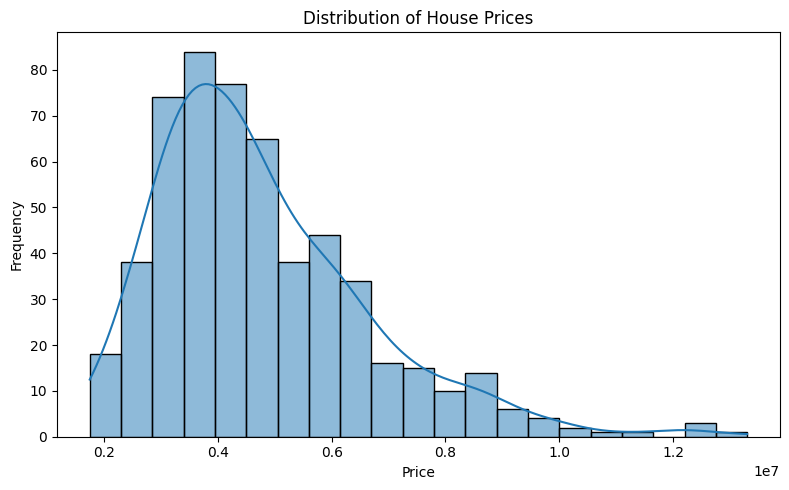

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(f"{PROJECT_NAME}/charts/price_distribution.png")
plt.show()

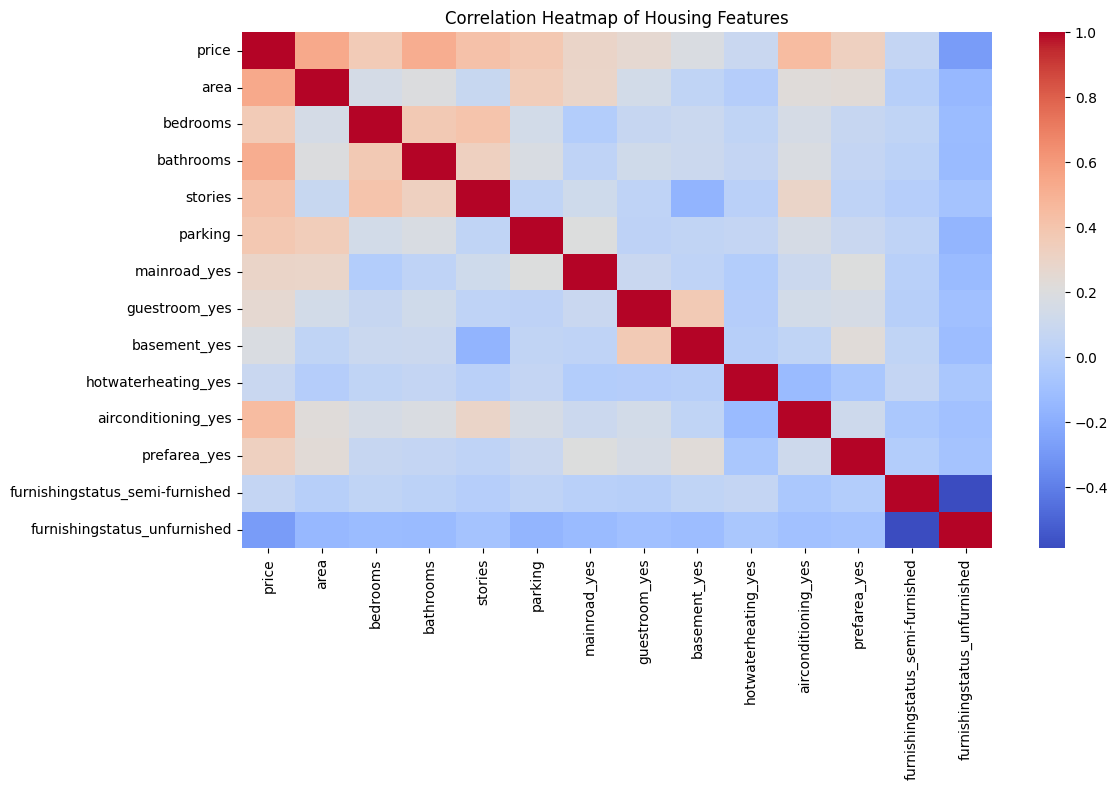

In [17]:
plt.figure(figsize=(12, 8))
correlation = df_encoded.corr()

sns.heatmap(correlation, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Housing Features")
plt.tight_layout()

plt.savefig(f"{PROJECT_NAME}/charts/correlation_heatmap.png")
plt.show()

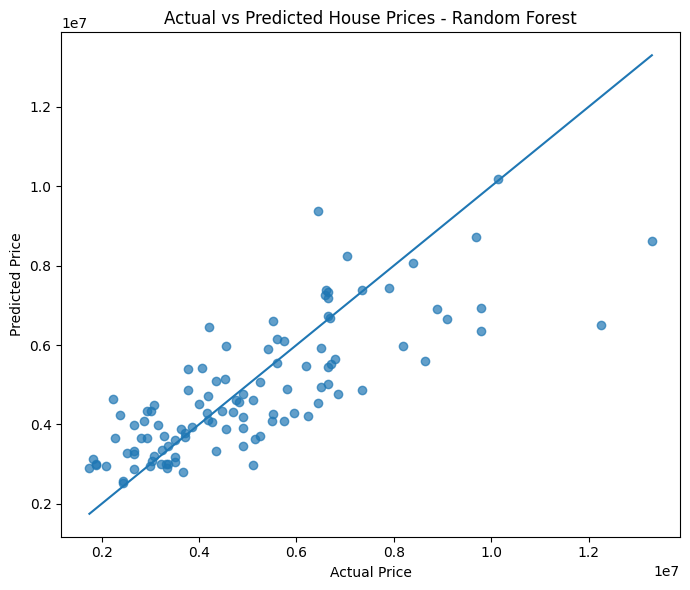

In [18]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, rf_predictions, alpha=0.7)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices - Random Forest")

min_price = min(y_test.min(), rf_predictions.min())
max_price = max(y_test.max(), rf_predictions.max())
plt.plot([min_price, max_price], [min_price, max_price])

plt.tight_layout()
plt.savefig(f"{PROJECT_NAME}/charts/actual_vs_predicted.png")
plt.show()

,Feature,Importance
0,area,0.468535
2,bathrooms,0.152554
9,airconditioning_yes,0.060238
4,parking,0.057273
3,stories,0.057064
1,bedrooms,0.047370
12,furnishingstatus_unfurnished,0.036972
7,basement_yes,0.032176
10,prefarea_yes,0.028432
8,hotwaterheating_yes,0.018305


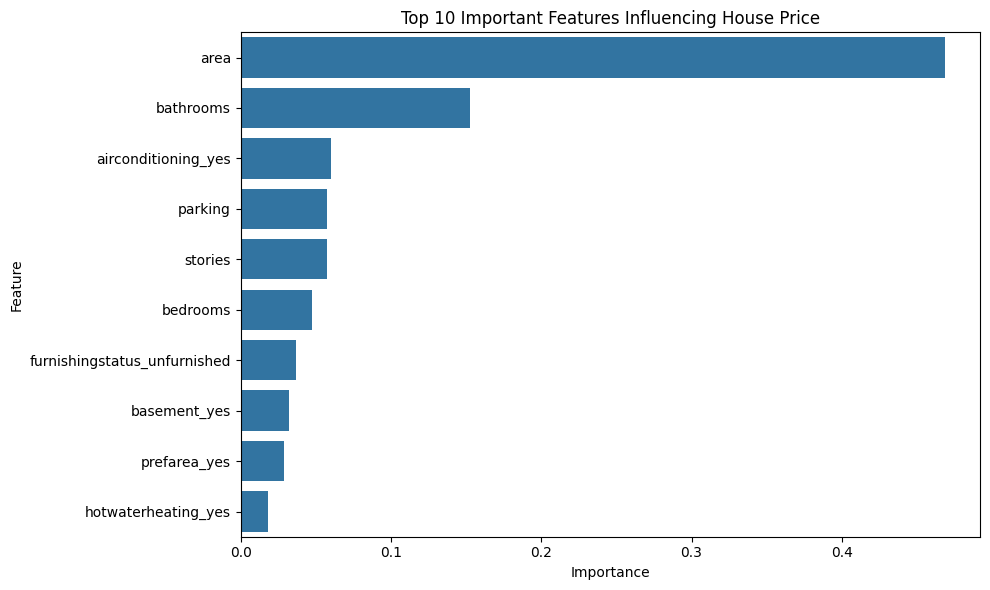

In [19]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

display(feature_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x="Importance", y="Feature")
plt.title("Top 10 Important Features Influencing House Price")
plt.tight_layout()

plt.savefig(f"{PROJECT_NAME}/charts/feature_importance.png")
plt.show()

In [20]:
summary_text = f"""
House Price Prediction - Summary
The target variable in this project is house price, and the model predicts it using features such as area, number of bedrooms, bathrooms, stories, parking, furnishing status, and other property facilities.
Based on the Random Forest feature importance, the most influential features are usually area, bathrooms, air conditioning, stories, parking, and location-related facilities such as preferred area. Area has a strong effect because larger houses generally have higher prices.
The Linear Regression model gave an R² score of {linear_r2:.2f}, while the Random Forest model gave an R² score of {rf_r2:.2f}. In simple terms, the model can explain a reasonable portion of price variation, but it is not perfect because house prices also depend on external factors such as exact location, market demand, neighborhood quality, and land value.
One surprising finding is that non-size features like air conditioning, preferred area, and furnishing status also affect price noticeably. This shows that buyers do not only pay for size, but also comfort and convenience.
A real estate business can use this model to estimate fair property prices quickly and identify which features increase property value the most. This can help sellers price homes better and help buyers avoid overpaying.
"""
print(summary_text)


House Price Prediction - Summary
The target variable in this project is house price, and the model predicts it using features such as area, number of bedrooms, bathrooms, stories, parking, furnishing status, and other property facilities.
Based on the Random Forest feature importance, the most influential features are usually area, bathrooms, air conditioning, stories, parking, and location-related facilities such as preferred area. Area has a strong effect because larger houses generally have higher prices.
The Linear Regression model gave an R² score of 0.65, while the Random Forest model gave an R² score of 0.61. In simple terms, the model can explain a reasonable portion of price variation, but it is not perfect because house prices also depend on external factors such as exact location, market demand, neighborhood quality, and land value.
One surprising finding is that non-size features like air conditioning, preferred area, and furnishing status also affect price noticeably. Thi

In [23]:
shutil.copy("Housing.csv", f"{PROJECT_NAME}/Housing.csv")

print("Housing.csv copied into project folder.")

Housing.csv copied into project folder.
